# Hladina C-reaktívneho proteínu

In [1]:
pip install xgboost catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 9.0 MB/s eta 0:00:00


In [2]:
pip install shap==0.44.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.7/535.7 kB 6.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from math import sqrt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import catboost as cb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import train_test_split



%matplotlib inline

In [ ]:
sns.set(style="whitegrid")

In [4]:
data = pd.read_excel("data_no_missing.xlsx")
original_data = data.copy()
data

,Derivation cohort,LOS,Death,Severity,Black,White,Asian,Latino,MI,PVD,...,Glucose,AST,ALT,WBC,Lympho,IL6,Ferritin,CrctProtein,Procalcitonin,Troponin
0,1,3,0,6,1,0,0,0,0,0,...,132,54.000,26.0,7.4,1.2,48.2000,1962.0,27.3000,0.3000,0.00999
1,1,6,0,4,0,1,0,0,0,0,...,115,135.000,243.0,5.9,1.1,5.3000,3043.0,11.1000,1.6000,0.01000
2,1,1,0,2,1,0,0,0,0,1,...,182,23.000,19.0,7.1,2.9,3.9999,87.0,0.8000,0.0999,0.00999
3,1,3,0,5,1,0,0,0,0,0,...,159,45.000,33.0,7.1,0.6,3.9999,3464.0,3.0000,1.3000,0.23000
4,1,14,0,3,0,0,0,1,0,0,...,127,84.000,43.0,3.6,0.4,11.8000,994.0,14.5000,0.2000,0.01000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,0,3,0,1,1,0,0,0,0,0,...,110,19.999,12.0,14.7,3.1,10.8000,254.0,1.9000,0.3000,0.01000
868,0,2,0,2,0,0,0,0,0,0,...,150,51.000,35.0,6.2,0.8,70.9000,184.0,4.1000,0.1000,0.01000
869,0,2,0,1,0,0,0,1,0,0,...,131,58.000,81.0,7.0,1.5,3.9999,73.0,0.4999,0.1000,0.01000
870,0,6,0,5,0,0,0,0,0,1,...,224,36.000,15.0,6.6,1.2,5.4000,750.0,21.1000,0.3000,0.01000


In [5]:
# Renaming columns
data = data.rename(columns={
    'LOS': 'Length_of_stay',
    'MI': 'Myocardial_infarction',
    'PVD': 'Per_vascular_dis',
    'CHF': 'Cong_heart_failure',
    'CVD': 'Cardiovascular_dis',
    'DEMENT': 'Dementia',
    'COPD': 'Chronic_obst_pulm_dis',
    'DM Complicated': 'Diabetes_mel_complicated',
    'DM Simple': 'Diabetes_mel_simple',
    'Renal Disease': 'Renal_dis',
    'All CNS': 'All_CNS',
    'Pure CNS': 'Pure_CNS',
    'OldOtherNeuro': 'Other_neuro_dis',
    'OtherBrnLsn': 'Other_brain_lesions',
    'Age.1': 'Age_number',
    'AgeScore': 'Age_category',
    'OsSats': 'Oxygen_sat',
    'Temp': 'Temperature',
    'MAP': 'Mean_art_press',
    'Plts': 'Platelets',
    'INR': 'Inter_norm_ratio',
    'BUN': 'Blood_urea_nitr',
    'WBC': 'White_blood_cells',
    'CrctProtein': 'CRP'
})


In [6]:
data['Per_vascular_dis'] = data['Per_vascular_dis'].replace(2, 1)

In [7]:
data_copy = data.copy()

In [8]:
data['CRP_int'] = data['CRP'].astype(int)

## Popis cieľového atribútu

<ipython-input-9-65bde4ab91f3>:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(new_labels, fontsize=12)


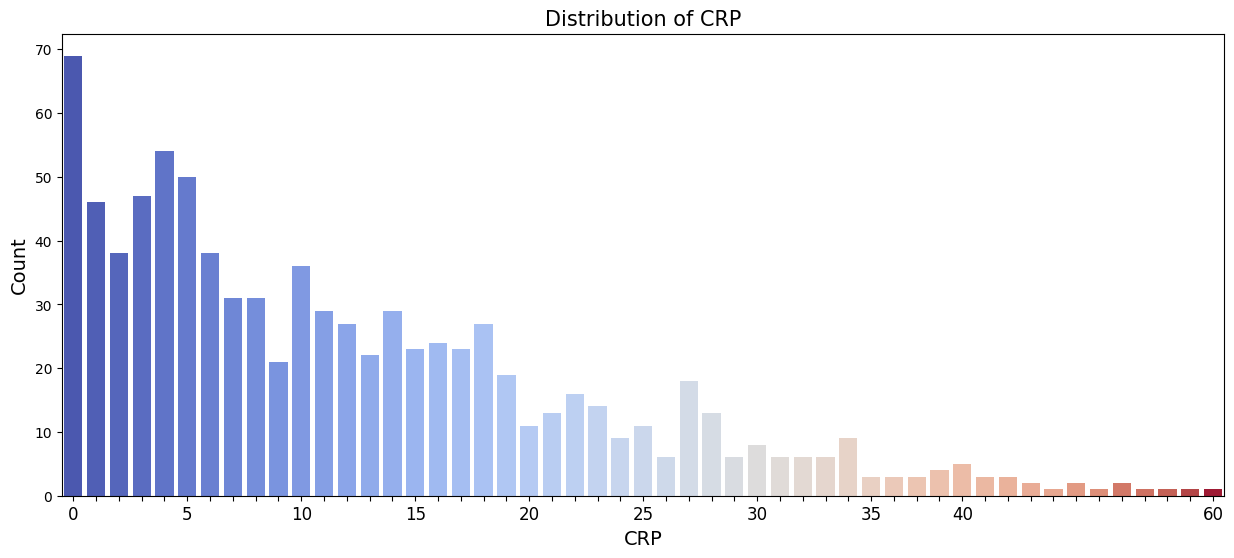

In [9]:
plt.figure(figsize=(15, 6))
sns.countplot(data=data, x="CRP_int", hue="CRP_int", palette="coolwarm", legend=False)

# Get current axis
ax = plt.gca()

# Get the tick labels and their corresponding positions
labels = [label.get_text() for label in ax.get_xticklabels()]
positions = ax.get_xticks()


start_pos = next(pos for pos, label in zip(positions, labels) if int(label) >= 1)

new_labels = ['' if int(label) % 5 != 0 else label for label in labels]
ax.set_xticklabels(new_labels, fontsize=12)

# Adding a title to the x-axis and y-axis
ax.set_xlabel("CRP", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
plt.title("Distribution of CRP", fontsize=15)
plt.show()


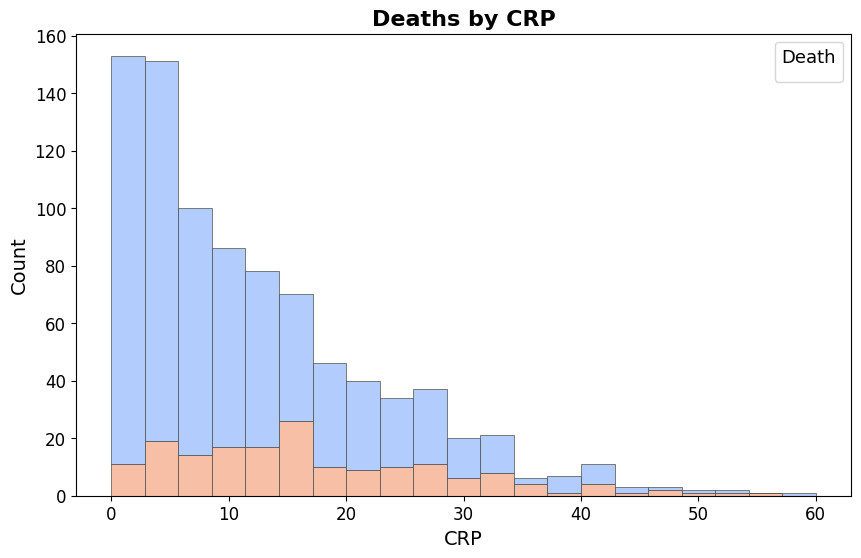

In [10]:
plt.figure(figsize=(10, 6))  # Slightly larger figure size for better clarity
plt.title('Deaths by CRP', fontsize=16, fontweight='bold')

# Enhanced histogram plot
sns.histplot(
    x='CRP_int',
    hue='Death',
    multiple="stack",
    data=data,
    palette="coolwarm",
    edgecolor='.3',
    linewidth=.5,
    alpha=0.9
)

plt.xlabel('CRP', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Death', title_fontsize='13', fontsize='12', loc='upper right')  # Enhanced legend

plt.show()


<Axes: title={'center': 'Deaths by CRP'}, xlabel='CRP_int', ylabel='Count'>

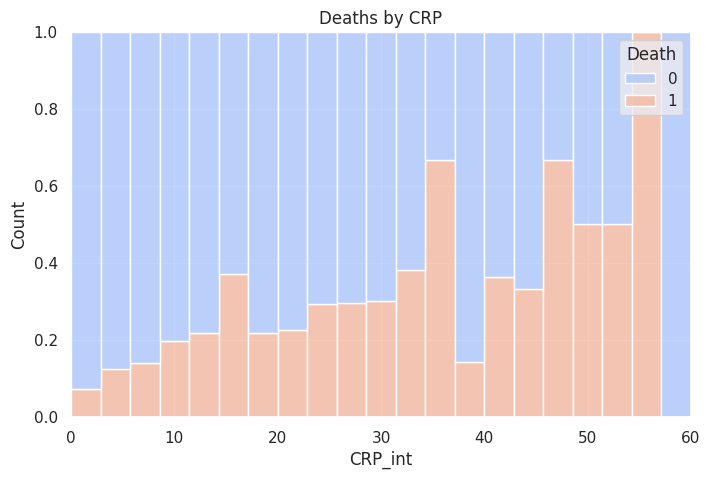

In [11]:
import seaborn as sns
sns.set()
plt.figure(figsize=(8,5))
plt.title('Deaths by CRP')
sns.histplot(x='CRP_int', hue='Death',multiple="fill", data=data, palette="coolwarm")

<ipython-input-12-db3ca15bd8cb>:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="Oxygen_sat", y="CRP",  data=data, palette="dark")


<Axes: xlabel='Oxygen_sat', ylabel='CRP'>

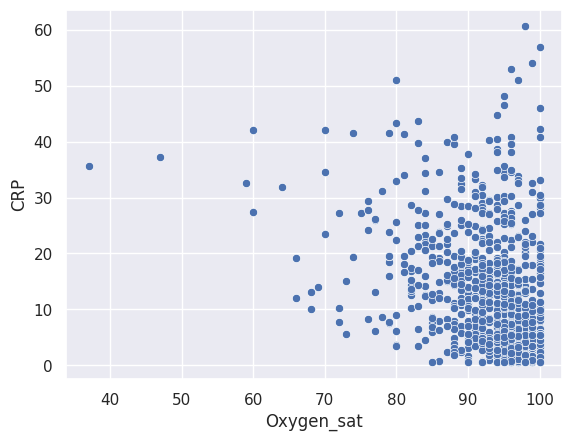

In [12]:
sns.scatterplot(x="Oxygen_sat", y="CRP",  data=data, palette="dark")

In [13]:
data = data.drop("CRP_int", axis=1)

# Rozdelenie atribútov na numerické a kategorické

In [14]:
numeric_features = data.columns[data.nunique() > 10]
numeric_features = numeric_features.drop("Severity")
print("Columnns that contain more than 10 values:\n", numeric_features)
print("Number of nuemrical features:", numeric_features.size)

Columnns that contain more than 10 values:
 Index(['Length_of_stay', 'Age2', 'Oxygen_sat', 'Temperature', 'Mean_art_press',
       'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr',
       'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells',
       'Lympho', 'IL6', 'Ferritin', 'CRP', 'Procalcitonin', 'Troponin'],
      dtype='object')
Number of nuemrical features: 21


In [15]:
categorical_features = data.columns[data.nunique() <=4]
categorical_features = categorical_features.drop("Death")
print("Columnns that contain less than 10 values:\n", categorical_features)
print("Number of categorical features:", categorical_features.size)

Columnns that contain less than 10 values:
 Index(['Derivation cohort', 'Black', 'White', 'Asian', 'Latino',
       'Myocardial_infarction', 'Per_vascular_dis', 'Cong_heart_failure',
       'Cardiovascular_dis', 'Dementia', 'Chronic_obst_pulm_dis',
       'Diabetes_mel_complicated', 'Diabetes_mel_simple', 'Renal_dis',
       'All_CNS', 'Pure_CNS', 'Stroke', 'Seizure', 'OldSyncope',
       'Other_neuro_dis', 'Other_brain_lesions', 'Age_category', 'PltsScore',
       'CrtnScore'],
      dtype='object')
Number of categorical features: 24


# Log transformácia (data_copy) numerických atribútov kvôli štatistickým testom

### Výber numerických atribútov

In [16]:
#show only column names with more than 2 unique values, discarding all boolean ones.
cols = ((data.dtypes != 'object') & (data.nunique() > 2))
cols = cols.drop(['CrtnScore','PltsScore','Age_category']) #drop items that show categories, scores, etc.

selectedColumns = list(cols[cols].index)
print(selectedColumns)
print(len(selectedColumns))

['Length_of_stay', 'Severity', 'Age2', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'IL6', 'Ferritin', 'CRP', 'Procalcitonin', 'Troponin']
22


## 2. Log transformation of DATA COPY

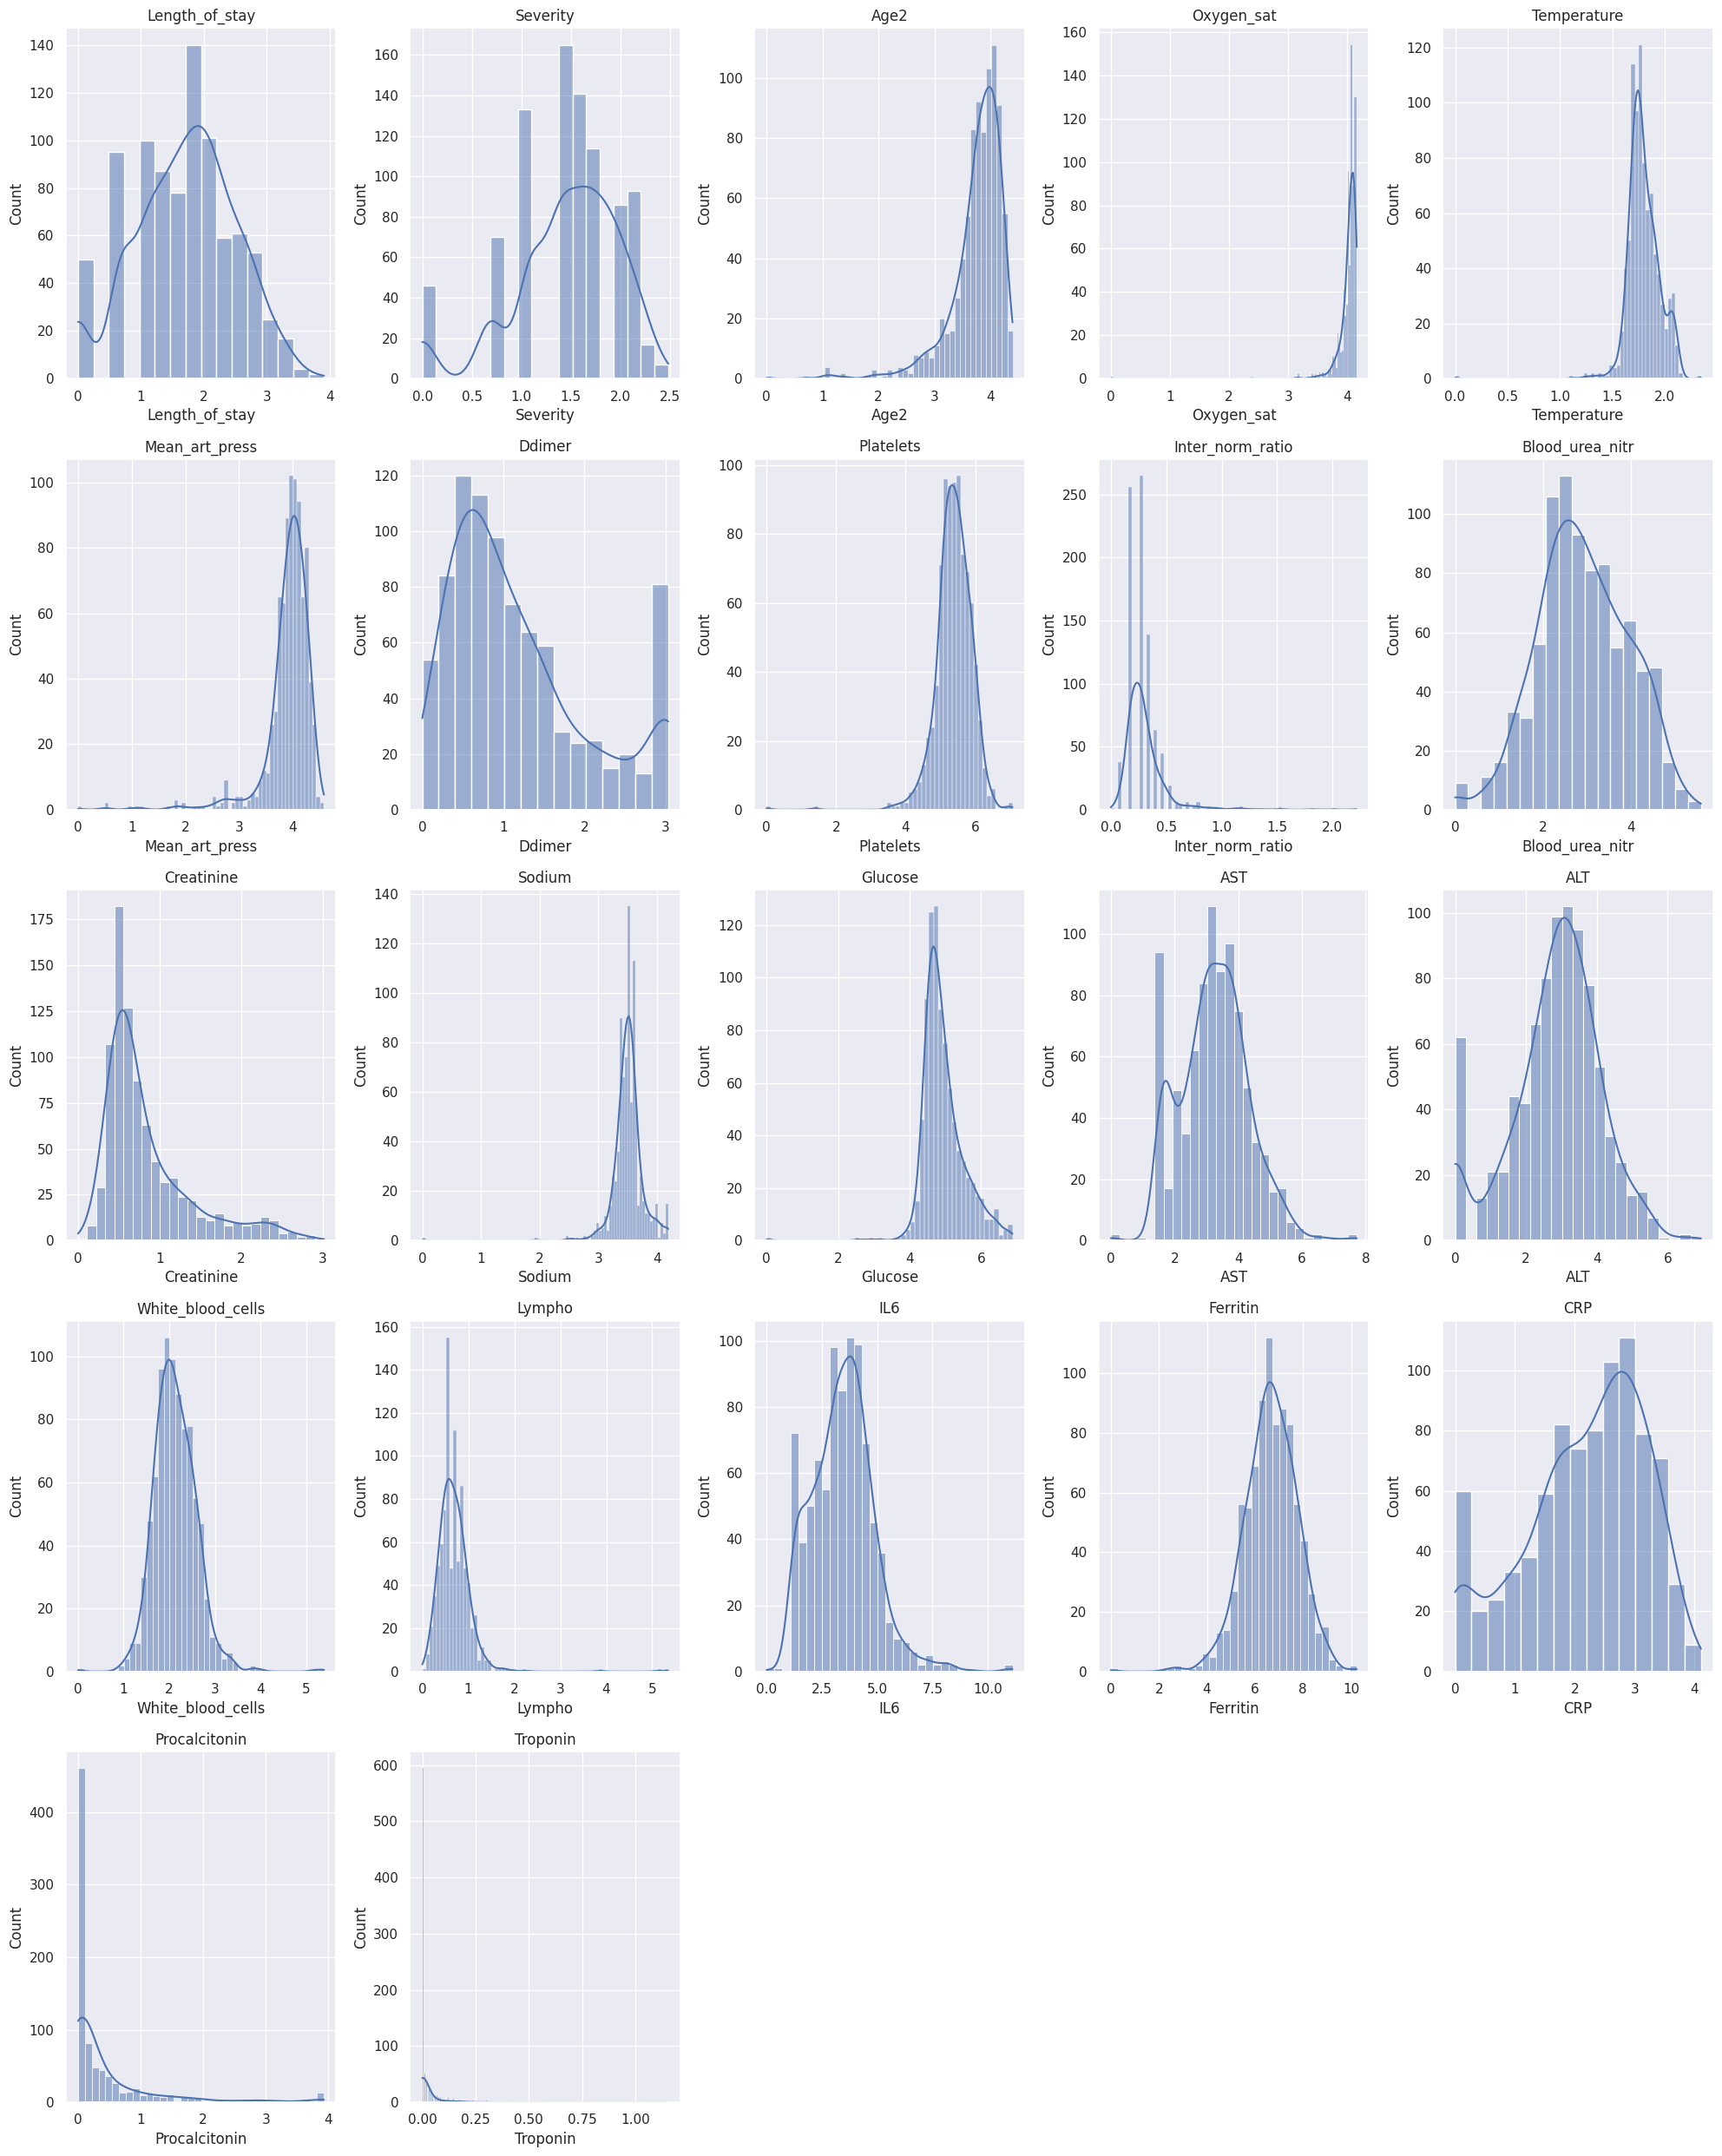

In [17]:

data_copy[selectedColumns] = data_copy[selectedColumns] + 1 - data_copy[selectedColumns].min()

# Apply log transformation
data_copy[selectedColumns] = np.log(data_copy[selectedColumns])


num_plots_in_row = 5
num_rows = (len(selectedColumns) + num_plots_in_row - 1) // num_plots_in_row
fig, axes = plt.subplots(nrows=num_rows, ncols=num_plots_in_row, figsize=(20, 5 * num_rows))

# Flatten the axes if there is more than one row
axes = axes.flatten()

# Plot the distribution of each numeric column
for i, column in enumerate(selectedColumns):
    sns.histplot(data_copy[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

# Remove any empty subplots
for j in range(len(selectedColumns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE

## Spearmanov koeficient

<ipython-input-18-6df99549c8a1>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
<ipython-input-18-6df99549c8a1>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')


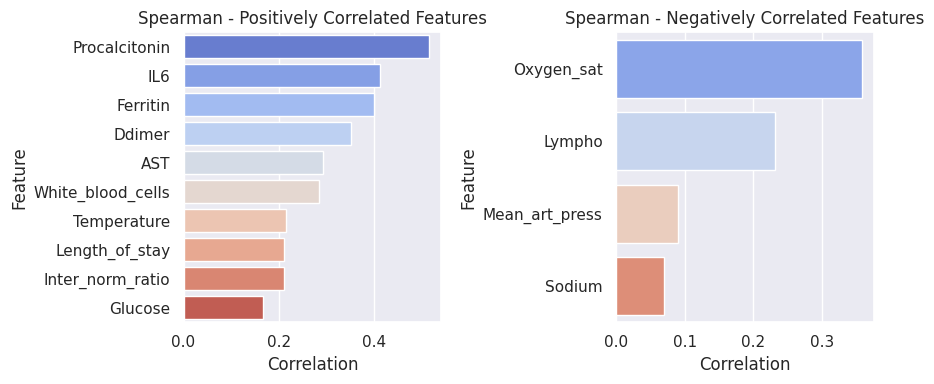

In [18]:

target_feature = 'CRP'

# Calculate Spearman correlation coefficients with the target variable
corr_with_target = data_copy[numeric_features].corr(method='spearman')[target_feature].drop(target_feature)

positive_correlations = corr_with_target[corr_with_target > 0]
negative_correlations = corr_with_target[corr_with_target < 0]

positive_correlations_sorted = positive_correlations.sort_values(ascending=False)
negative_correlations_sorted = negative_correlations.abs().sort_values(ascending=False)

# Extract the top correlated features (both positively and negatively)
n_top_features = 10

# Plot the most positively correlated features
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Spearman - Positively Correlated Features')

# Plot the most negatively correlated features
plt.subplot(1, 2, 2)
sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Spearman - Negatively Correlated Features')

plt.tight_layout()
plt.show()

## Kendallov koeficient pre zistenie vplyvu kategorických atr. na numerický

<ipython-input-19-c9945e188e20>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
<ipython-input-19-c9945e188e20>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')


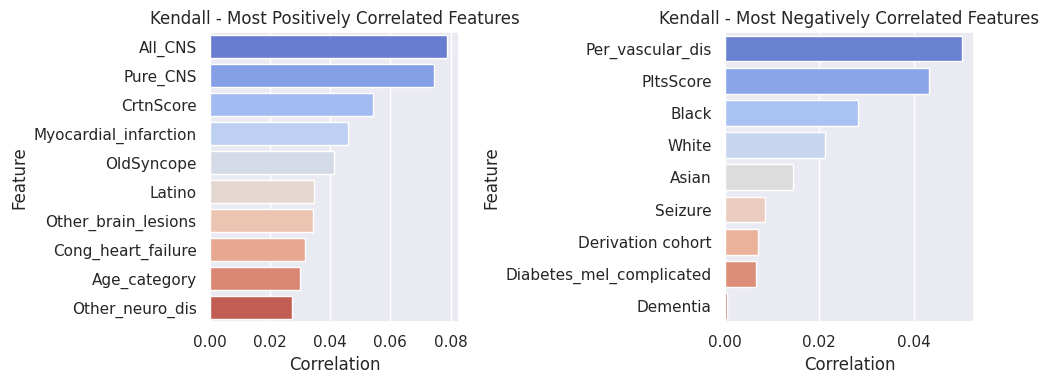

In [19]:
target_feature = 'CRP'
corr_with_target = data_copy[categorical_features].apply(lambda x: x.corr(data_copy[target_feature], method='kendall'))

# Split correlations into positive and negative
positive_correlations = corr_with_target[corr_with_target > 0]
negative_correlations = corr_with_target[corr_with_target < 0]

# Sort the correlations by their absolute values in descending order
positive_correlations_sorted = positive_correlations.sort_values(ascending=False)
negative_correlations_sorted = negative_correlations.abs().sort_values(ascending=False)

# Extract the top correlated features (both positively and negatively)
n_top_features = 10

# Plot the most positively correlated features
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Kendall - Most Positively Correlated Features')

# Plot the most negatively correlated features
plt.subplot(1, 2, 2)
sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.title(f'Kendall - Most Negatively Correlated Features')

plt.tight_layout()
plt.show()


## ANOVA pre vplyv kategorických atr. na numerický

ANOVA Test Results:
Feature		P-Value
Seizure		5.717792142371311e-10
Stroke		0.020721116694496697
OldSyncope		0.08129168068049904
Other_brain_lesions		0.08252308310615088
Diabetes_mel_complicated		0.18379217604803388
Diabetes_mel_simple		0.22763603096584686
Chronic_obst_pulm_dis		0.2954514218070182
Myocardial_infarction		0.3652296128017886
Latino		0.37295940690001583
Cong_heart_failure		0.39309707611465994
Pure_CNS		0.4042572955373367
All_CNS		0.45078446833872565
CrtnScore		0.4630990388000196
Renal_dis		0.48334108690447997
Cardiovascular_dis		0.576457166555308
PltsScore		0.6326320059062374
Age_category		0.6997991161917102
Derivation cohort		0.8977680431473845
Other_neuro_dis		0.9093513357706782
White		0.9595283686128696
Black		0.9827733640127305
Dementia		0.9954800184798448
Per_vascular_dis		0.9986503282601294
Asian		0.9998021562677459


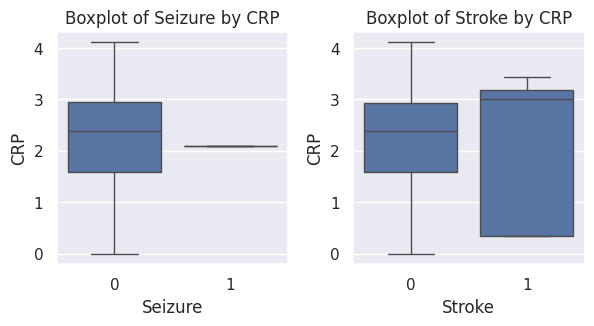

In [20]:
df = pd.DataFrame(data_copy)

# Perform ANOVA test for numeric features
f_stat, p_values_anova = f_classif(df[categorical_features], df['CRP'])

# Display p-values in ascending order
print("ANOVA Test Results:")
print("Feature\t\tP-Value")
sorted_p_values_anova = sorted(zip(categorical_features, p_values_anova), key=lambda x: x[1])
for feature, p_value_anova in sorted_p_values_anova:
    print(f"{feature}\t\t{p_value_anova}")

# Visualize boxplots for significant features
significant_features = [feature for feature, p_value in sorted_p_values_anova if p_value < 0.05]

# Create subplots for boxplots
plt.figure(figsize=(15, 15))
for i, feature in enumerate(significant_features, 1):
    plt.subplot(5, 5, i)  # 2 rows, 5 columns
    sns.boxplot(y='CRP', x=feature, data=df)
    plt.title(f'Boxplot of {feature} by CRP')
    plt.xlabel(feature)
    plt.ylabel('CRP')
plt.tight_layout()
plt.show()


## Boxplots na pôvodných dátach

<ipython-input-21-b75eb8fe2584>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='CRP', x=feature, data=data, palette="coolwarm", ax=axes[i])
<ipython-input-21-b75eb8fe2584>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='CRP', x=feature, data=data, palette="coolwarm", ax=axes[i])


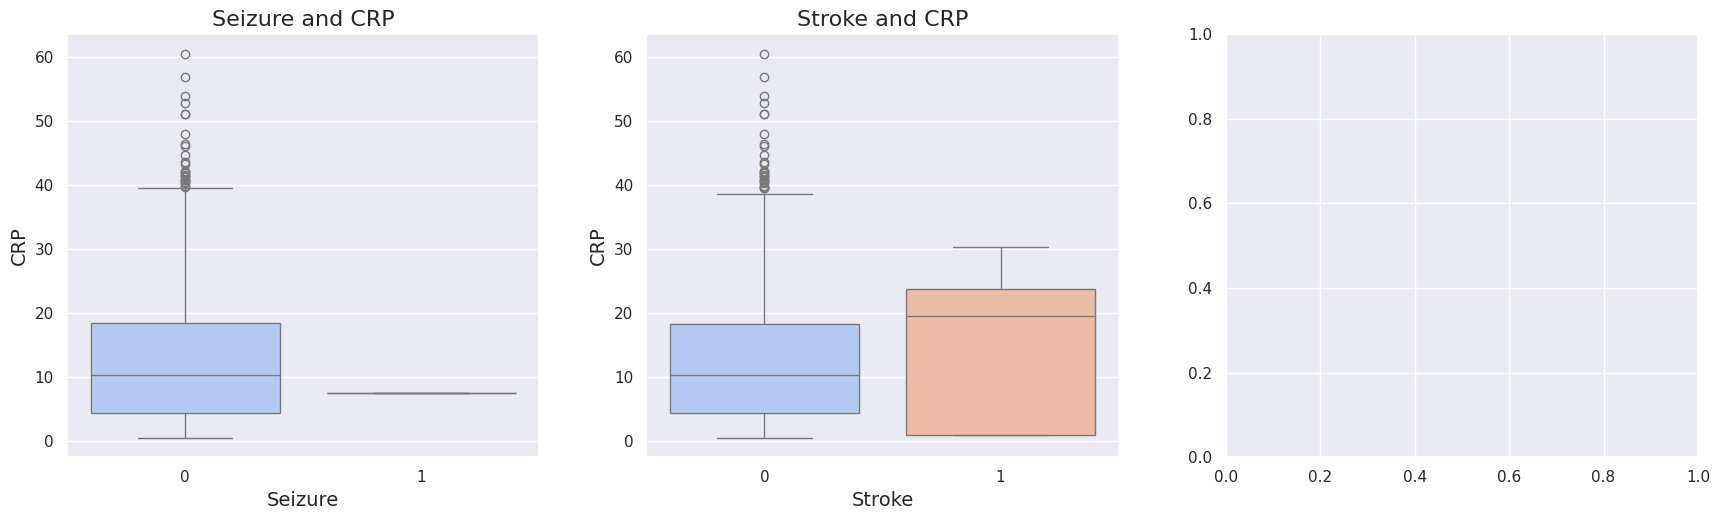

In [21]:
top_3_features = significant_features[:3]

# Setup the matplotlib figure for a 1x3 subplot layout, all in one row
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Iterate over the top 3 significant features and create boxplots for each
for i, feature in enumerate(top_3_features):
    sns.boxplot(y='CRP', x=feature, data=data, palette="coolwarm", ax=axes[i])
    axes[i].set_title(f'{feature} and CRP', fontsize=16)
    axes[i].set_xlabel(feature, fontsize=14)
    axes[i].set_ylabel('CRP', fontsize=14)

plt.tight_layout(pad=3.0)

plt.show()

In [ ]:
feature_names=X.columns

# Normalizácia -  pre modelovanie

### Výber numerických atribútov na normalizáciu, okrem cieľovej premennej atd


In [22]:
#show only column names with more than 2 unique values, discarding all boolean ones.
cols = ((data.dtypes != 'object') & (data.nunique() > 2))
cols = cols.drop(['CRP', 'CrtnScore','PltsScore','Age_category']) #drop items that show categories, scores, etc.

selectedColumns = list(cols[cols].index)
print(selectedColumns)
print(len(selectedColumns))

['Length_of_stay', 'Severity', 'Age2', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'IL6', 'Ferritin', 'Procalcitonin', 'Troponin']
21


Numeric features distributions

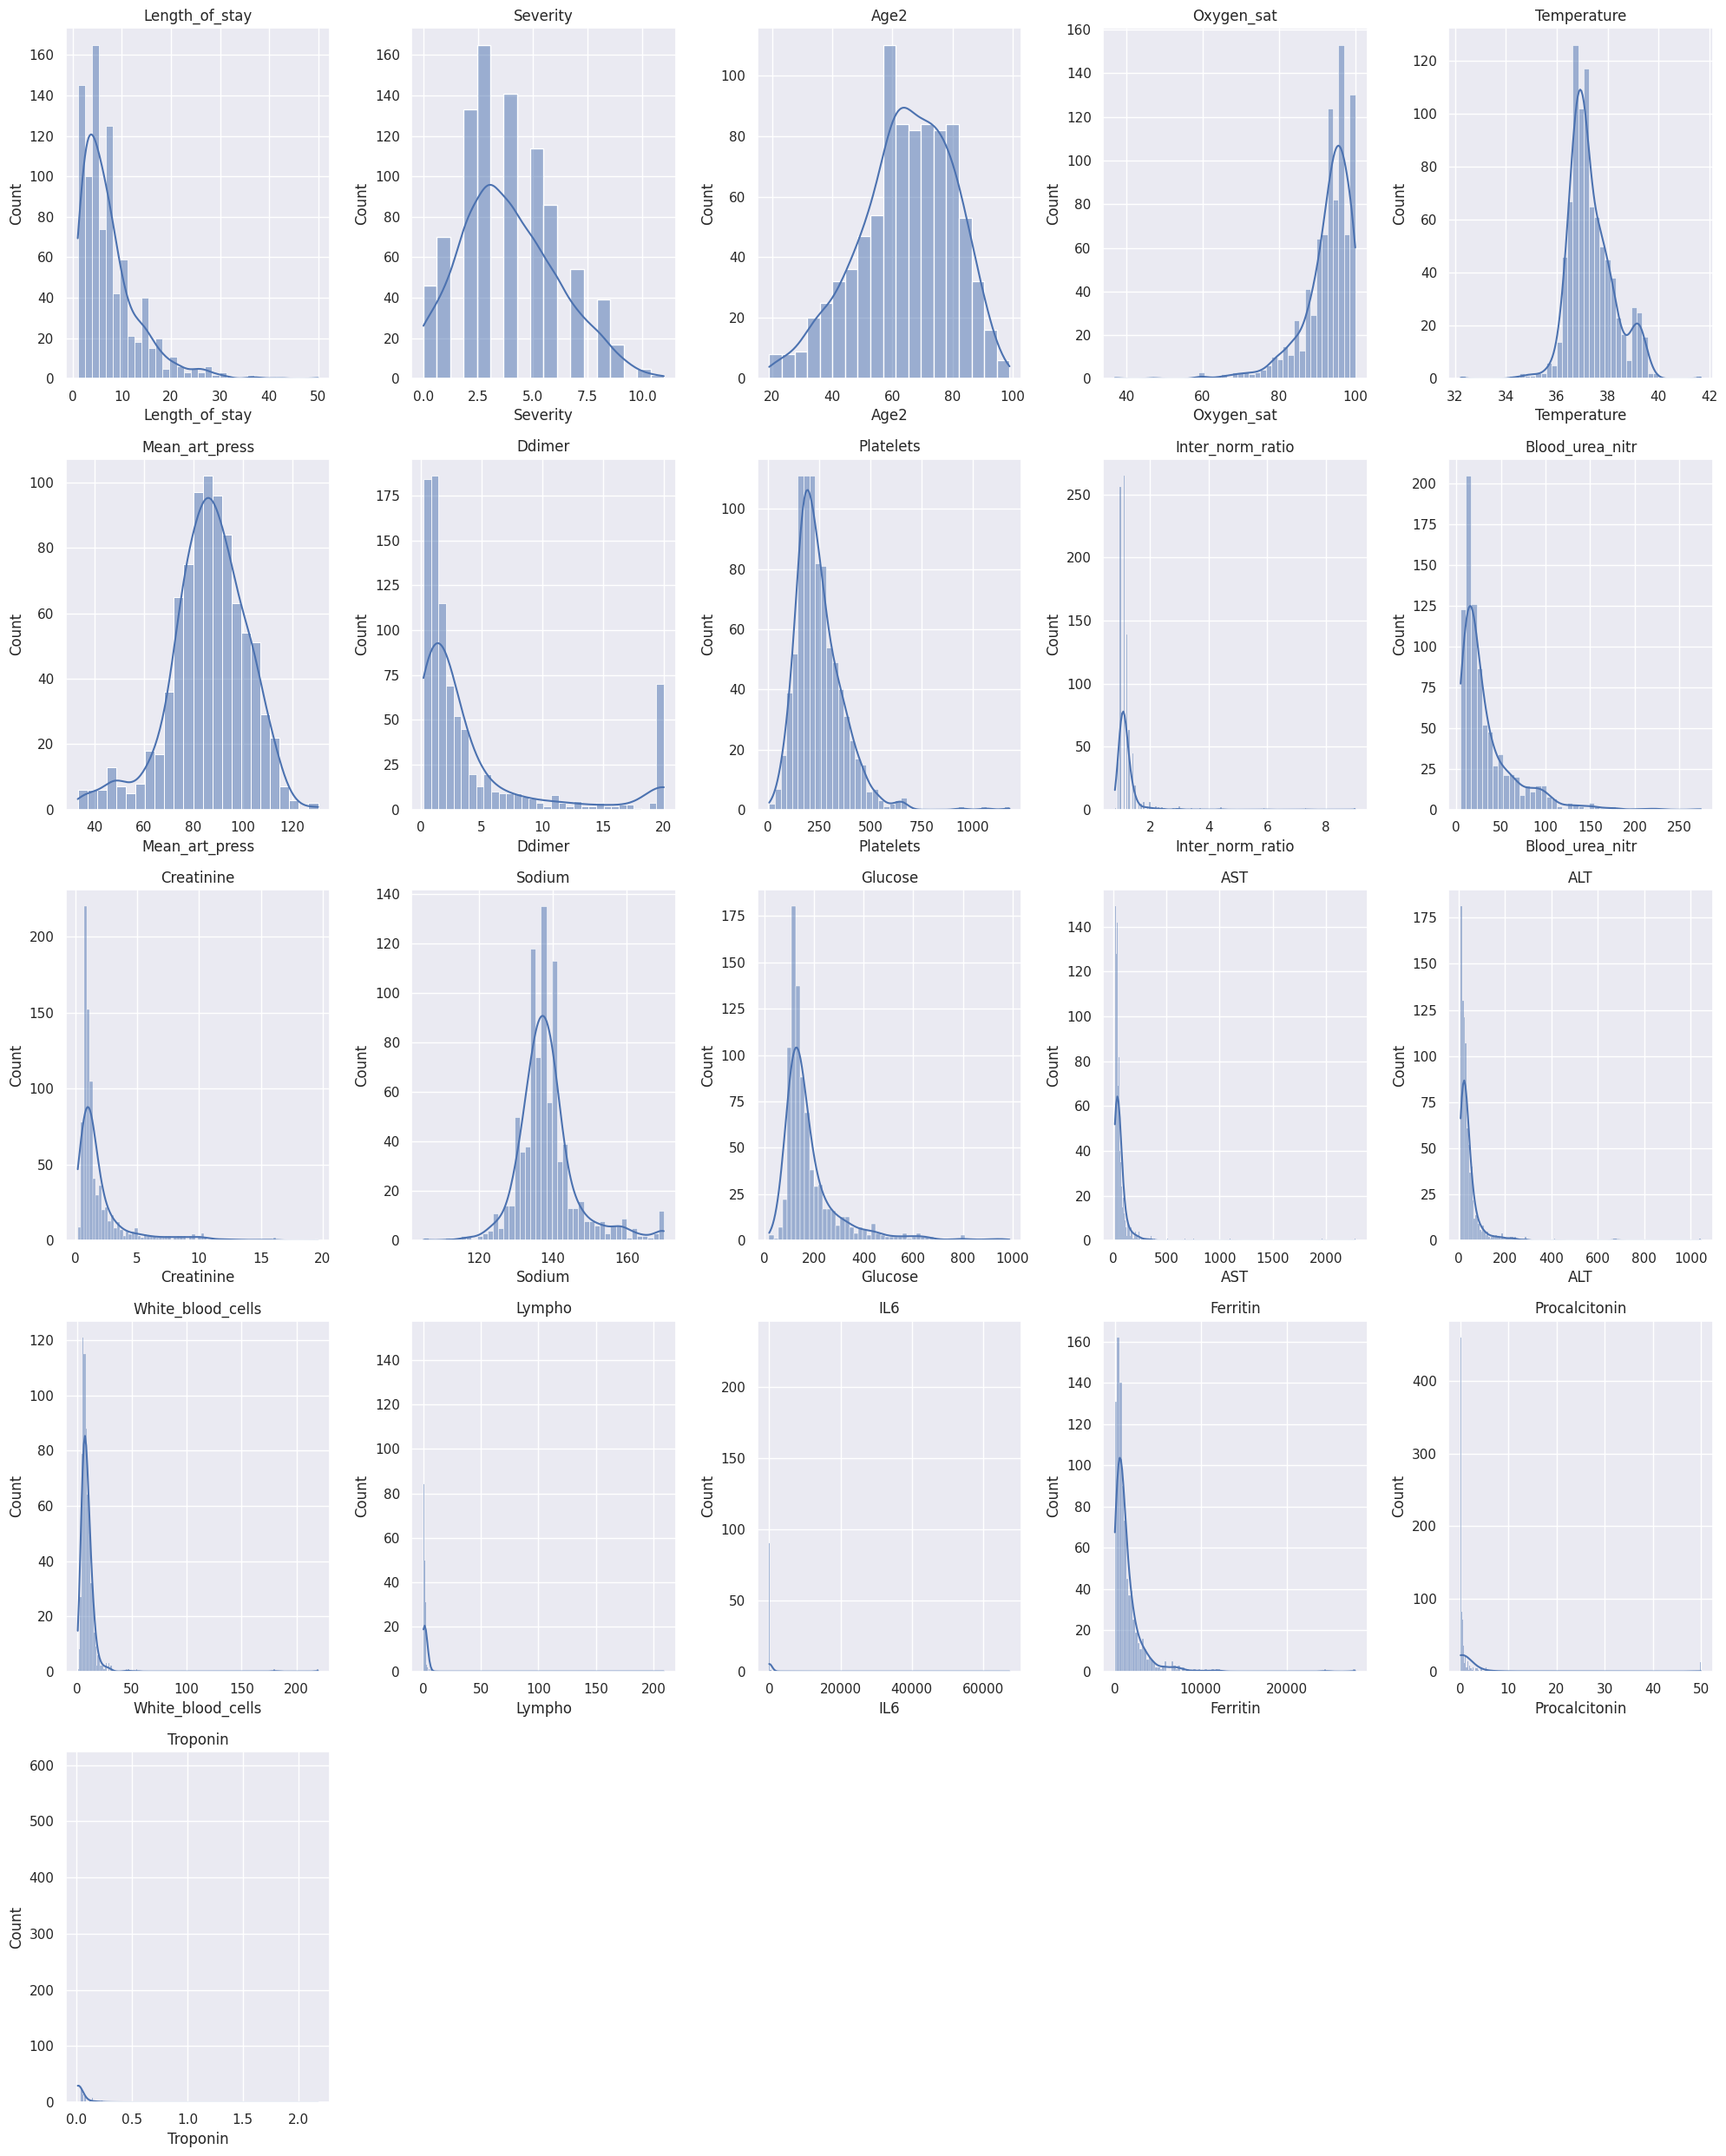

In [23]:
num_plots_in_row = 5
num_rows = (len(selectedColumns) + num_plots_in_row - 1) // num_plots_in_row
fig, axes = plt.subplots(nrows=num_rows, ncols=num_plots_in_row, figsize=(20, 5 * num_rows))

# Flatten the axes if there is more than one row
axes = axes.flatten()

# Plot the distribution of each numeric column
for i, column in enumerate(selectedColumns):
    sns.histplot(data[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

# Remove any empty subplots
for j in range(len(selectedColumns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Standard Scaler

In [24]:
from sklearn.preprocessing import StandardScaler, RobustScaler
# Select the columns we want to normalize
columns_to_normalize = selectedColumns

# Create a new DataFrame for the columns to normalize
data_to_normalize = data[columns_to_normalize]

# Normalize using Min-Max scaling
standard_scaler = StandardScaler()
data_to_normalize_minmax = standard_scaler.fit_transform(data_to_normalize)

# Update the original DataFrame with the normalized values
data[columns_to_normalize] = data_to_normalize_minmax

data.head(5)

,Derivation cohort,Length_of_stay,Death,Severity,Black,White,Asian,Latino,Myocardial_infarction,Per_vascular_dis,...,Glucose,AST,ALT,White_blood_cells,Lympho,IL6,Ferritin,CRP,Procalcitonin,Troponin
0,1,-0.735599,0,0.945490,1,0,0,0,0,0,...,-0.425913,-0.091402,-0.295404,-0.194421,-0.048318,-0.067319,0.292748,27.3,-0.251006,-0.253109
1,1,-0.241675,0,0.047377,0,1,0,0,0,0,...,-0.554445,0.576364,3.179095,-0.338855,-0.059171,-0.081546,0.841690,11.1,-0.079523,-0.253046
2,1,-1.064882,0,-0.850735,1,0,0,0,0,1,...,-0.047879,-0.346967,-0.407485,-0.223308,0.136191,-0.081977,-0.659395,0.8,-0.277402,-0.253109
3,1,-0.735599,0,0.496434,1,0,0,0,0,0,...,-0.221774,-0.165598,-0.183324,-0.223308,-0.113439,-0.081977,1.055478,3.0,-0.119096,1.139518
4,1,1.075455,0,-0.401679,0,0,0,1,0,0,...,-0.463717,0.155919,-0.023209,-0.560319,-0.135146,-0.079390,-0.198812,14.5,-0.264197,-0.253046


## Vytvorenie pomocných "dummies" atribútov pre kategorické atribúty

In [25]:
# get_dummies to create dummy variables for each categorical column
data = pd.get_dummies(data, columns=['CrtnScore', 'PltsScore', 'Age_category'], prefix=['CrtnScore', 'PltsScore', 'AgeScore'])

data.head(5)

,Derivation cohort,Length_of_stay,Death,Severity,Black,White,Asian,Latino,Myocardial_infarction,Per_vascular_dis,...,CrtnScore_0,CrtnScore_1,CrtnScore_2,PltsScore_0,PltsScore_1,PltsScore_2,AgeScore_0,AgeScore_1,AgeScore_2,AgeScore_3
0,1,-0.735599,0,0.945490,1,0,0,0,0,0,...,True,False,False,True,False,False,False,False,False,True
1,1,-0.241675,0,0.047377,0,1,0,0,0,0,...,True,False,False,True,False,False,False,True,False,False
2,1,-1.064882,0,-0.850735,1,0,0,0,0,1,...,True,False,False,True,False,False,False,True,False,False
3,1,-0.735599,0,0.496434,1,0,0,0,0,0,...,False,False,True,True,False,False,False,False,True,False
4,1,1.075455,0,-0.401679,0,0,0,1,0,0,...,True,False,False,True,False,False,True,False,False,False


In [26]:
data.columns

Index(['Derivation cohort', 'Length_of_stay', 'Death', 'Severity', 'Black',
       'White', 'Asian', 'Latino', 'Myocardial_infarction', 'Per_vascular_dis',
       'Cong_heart_failure', 'Cardiovascular_dis', 'Dementia',
       'Chronic_obst_pulm_dis', 'Diabetes_mel_complicated',
       'Diabetes_mel_simple', 'Renal_dis', 'All_CNS', 'Pure_CNS', 'Stroke',
       'Seizure', 'OldSyncope', 'Other_neuro_dis', 'Other_brain_lesions',
       'Age2', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer',
       'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine',
       'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'IL6',
       'Ferritin', 'CRP', 'Procalcitonin', 'Troponin', 'CrtnScore_0',
       'CrtnScore_1', 'CrtnScore_2', 'PltsScore_0', 'PltsScore_1',
       'PltsScore_2', 'AgeScore_0', 'AgeScore_1', 'AgeScore_2', 'AgeScore_3'],
      dtype='object')

In [27]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5).fit(data_copy[numeric_features], data_copy['CRP'])
important_features = [feature for feature, coef in zip(numeric_features, lasso.coef_) if coef != 0]
print('Important features:', important_features)


Important features: ['CRP']


In [28]:
X = data.drop(columns=["Death","Severity", "CRP"]) #

y = data["CRP"]

In [29]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating and fitting the Lasso Regression model
lasso = Lasso(alpha=0.1)  # Alpha is the regularization strength
lasso.fit(X_train, y_train)

# Making predictions
y_pred = lasso.predict(X_test)

# Calculating Mean Squared Error (MSE) on test set
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Get the coefficients and corresponding feature names
coefficients = lasso.coef_
feature_names = [f'Feature {i}' for i in range(X.shape[1])]


Mean Squared Error: 99.5349133180609


## LASSO REGRESSION

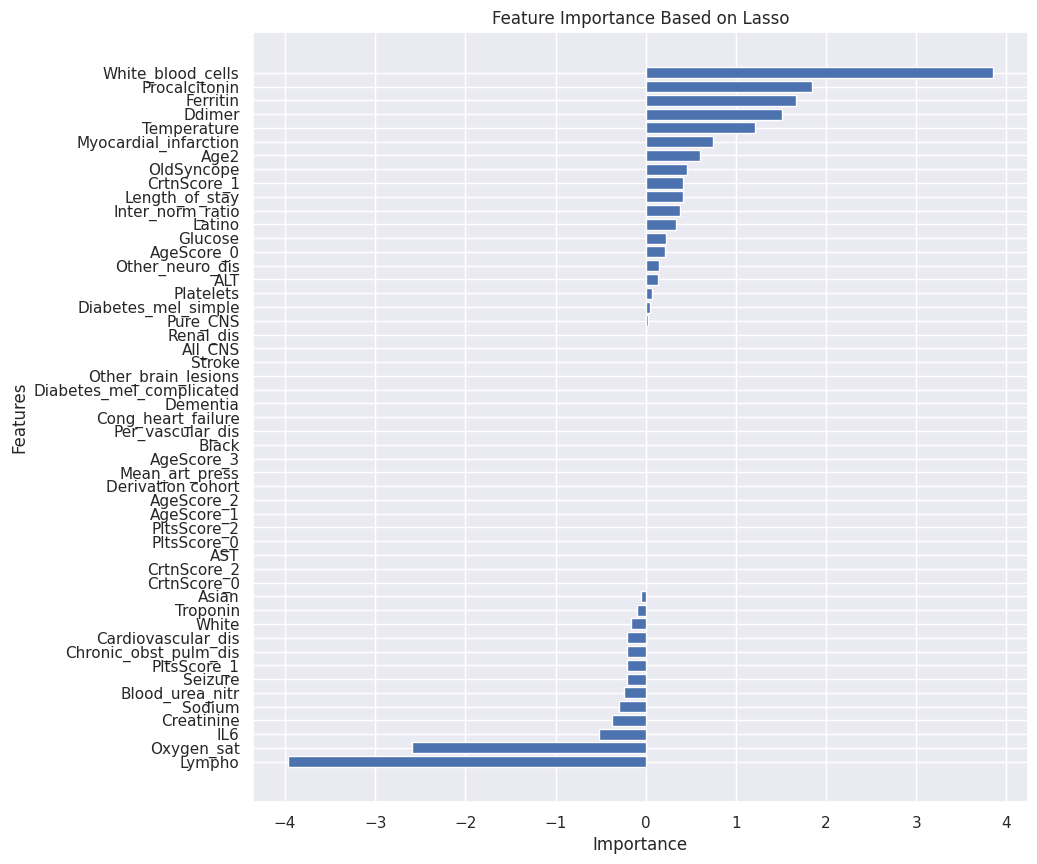

In [30]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardizing the features if not already done
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

# Getting the coefficients
coefficients = lasso.coef_

# Sort feature importance coefficients
sorted_indices = np.argsort(coefficients)

# Get sorted feature names and importance values
sorted_features = np.array(X_train.columns)[sorted_indices]
sorted_importance = coefficients[sorted_indices]

# Plotting
plt.figure(figsize=(10,10))
plt.barh(sorted_features, sorted_importance)
plt.grid(True)
plt.title("Feature Importance Based on Lasso")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

# PREDICTING CRP

In [31]:
X = data.drop(columns=["Death","Severity","CRP"]) # "oxygen_sat_class" !!!!

y = data["CRP"]

In [32]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X,y, test_size=0.2, random_state=42)
print("Train_x :",train_x.shape)
print("Test_x :",test_x.shape)
print("Train_y :",train_y.shape)
print("Test_y :",test_y.shape)

Train_x : (697, 51)
Test_x : (175, 51)
Train_y : (697,)
Test_y : (175,)


# Všetky modely - porovnanie podľa MAE

In [35]:
# Define a basic sequential model for regression
def create_sequential_model(input_shape):
    model = Sequential([
        Dense(64, activation='relu', input_shape=input_shape),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(), loss='mean_squared_error')
    return model

# Define regression models to test
models = [
    ('LinearRegression', LinearRegression()),
    ('Ridge', Ridge()),
    ('Lasso', Lasso()),
    ('RandomForest', RandomForestRegressor()),
    ('LGBMRegressor', LGBMRegressor(max_iter=1000)),
    ('SVR', SVR()),
    ('KNN', KNeighborsRegressor()),
    ('XGBRegressor', xgb.XGBRegressor()),
    ('CatBoostRegressor', cb.CatBoostRegressor(verbose=0)),  # verbose=0 to keep the output clean
    # Adding a placeholder for the Sequential model; we'll handle it separately
    #('SequentialNN', 'placeholder_for_keras_model')
]

results_table = []

for name, model in models:
    if name == 'SequentialNN':
        # Create and train the Sequential model
        model = create_sequential_model((train_x.shape[1],))
        history = model.fit(train_x, train_y, epochs=10, batch_size=32, verbose=0)
        predictions = model.predict(test_x).flatten()  # Flatten predictions
    else:
        # Train the model
        model.fit(train_x, train_y)
        # Make predictions
        predictions = model.predict(test_x)

    # Calculate metrics
    mae = mean_absolute_error(test_y, predictions)
    mse = mean_squared_error(test_y, predictions)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(test_y, predictions)

    # Store results
    results_table.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    })

# Convert results table to a DataFrame for better visualization
results_df = pd.DataFrame(results_table)

# Round the DataFrame to three decimal places
results_df = results_df.round(3)

results_df.sort_values(by='MAE', inplace=True)

# Display the DataFrame
print(results_df)


/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:172: UserWarning: Found `max_iter` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Warning] num_iterations is set=1000, max_iter=1000 will be ignored. Current value: num_iterations=1000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2133
[LightGBM] [Info] Number of data points in the train set: 697, number of used features: 45
[LightGBM] [Info] Start training from score 12.771015
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [42]:
sns.set_style("ticks")

## LGB Regressor

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2133
[LightGBM] [Info] Number of data points in the train set: 697, number of used features: 45
[LightGBM] [Info] Start training from score 12.771015
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

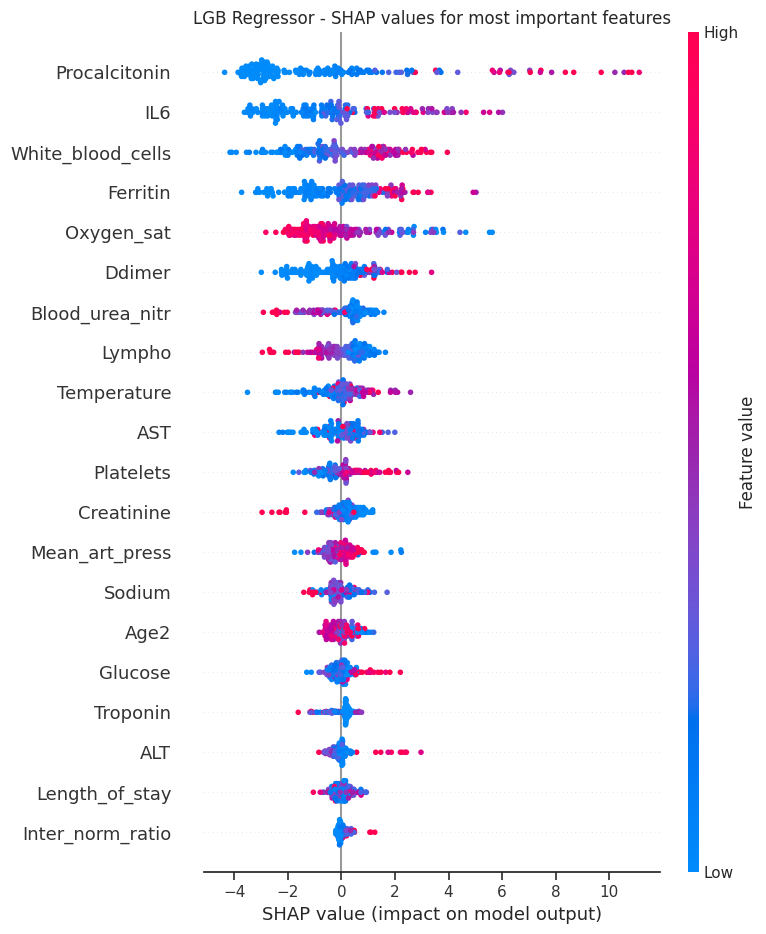

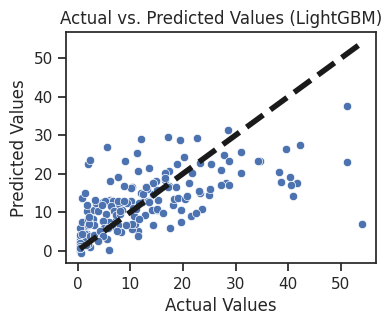

In [45]:
import shap
# Create an LightGBM regression model
lgb_regressor = lgb.LGBMRegressor(random_state=42)
lgb_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = lgb_regressor.predict(test_x)

# Evaluate the LightGBM model
mse = mean_squared_error(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, pred_y)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

explainer = shap.TreeExplainer(lgb_regressor)

shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
plt.figure(figsize=(3, 7))
plt.title("LGB Regressor - SHAP values for most important features")
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(4, 3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (LightGBM)")
plt.plot([min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], [min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], 'k--', lw=4)
plt.show()


## SVR

Mean Absolute Error: 7.208297587413264
MSE: 114.11685770640499
RMSE: 10.682549213853639


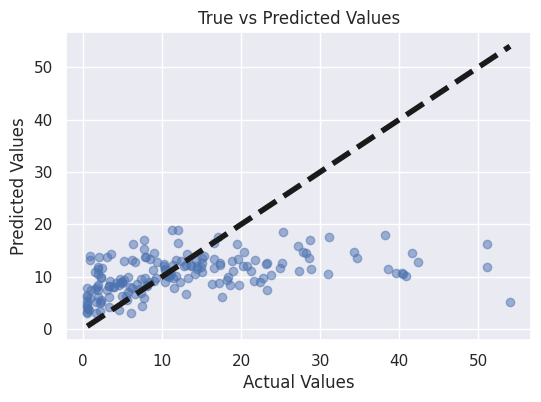

In [41]:
# Create and fit the SVR model
svr = SVR()
svr.fit(train_x, train_y)

y_pred = svr.predict(test_x)

# Evaluate the SVR model in the original scale
mse = mean_squared_error(test_y, y_pred)
mape = mean_absolute_percentage_error(test_y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

# Plotting true vs predicted values in original scale
plt.figure(figsize=(6, 4))
plt.scatter(test_y, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.plot([min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], [min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], 'k--', lw=4)
plt.show()


## SVR C=1, epsilon=0.2)

Mean Absolute Error: 7.2032414612967255
Mean Squared Error: 113.85335022193719


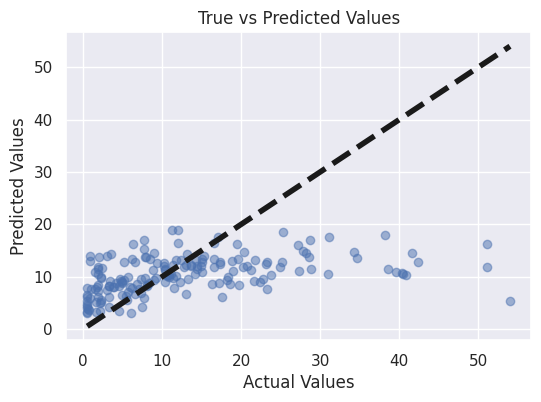

In [40]:
model = SVR(C=1, epsilon=0.2)

# Fit the model
model.fit(train_x, train_y)

# Predict
y_pred = model.predict(test_x)

# Evaluate the model
print(f"Mean Absolute Error: {mean_absolute_error(test_y, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(test_y, y_pred)}")

# Plotting true vs predicted values
plt.figure(figsize=(6, 4))
plt.scatter(test_y, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
# Use min and max from both actual and predicted values for a more accurate line
plt.plot([min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], [min(test_y.min(), y_pred.min()), max(test_y.max(), y_pred.max())], 'k--', lw=4)
plt.show()


## CatBoost Regressor

Mean Absolute Error: 6.2420264978598805
MSE: 79.95877652885868
RMSE: 8.941967150960615
R²: 0.39045404528528327


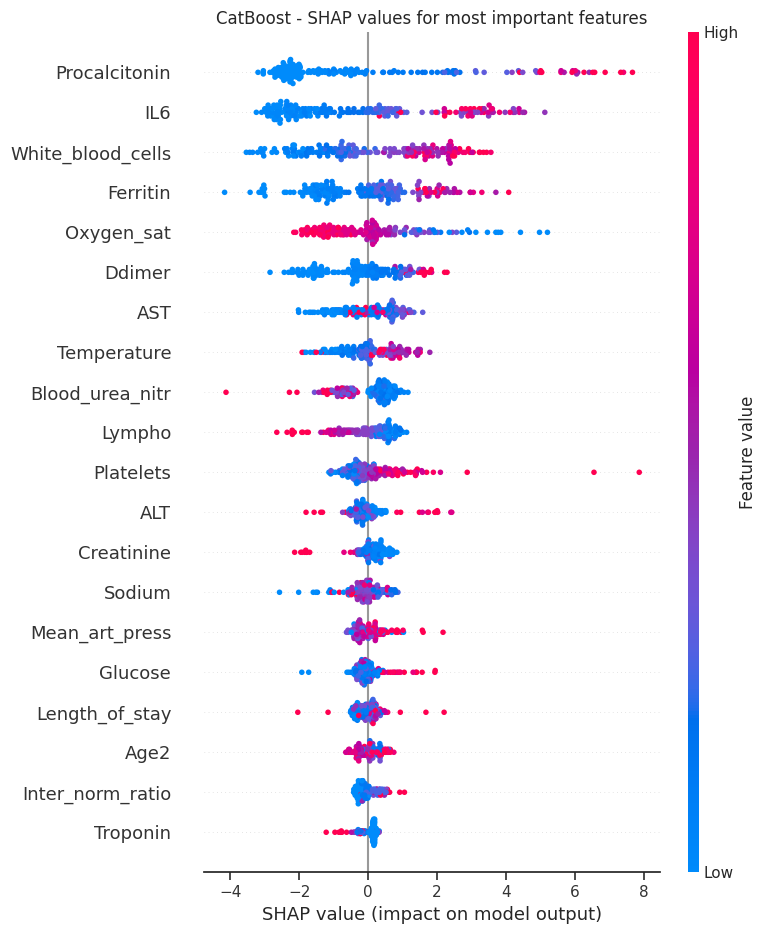

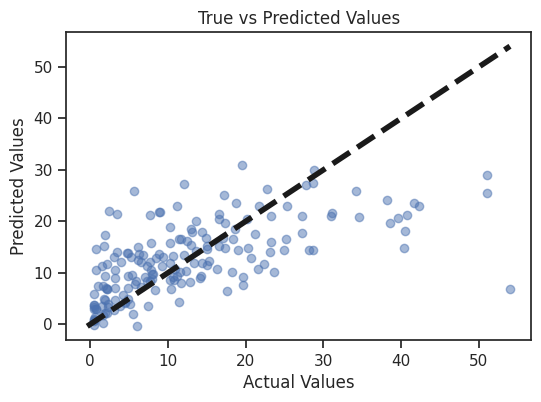

In [47]:
import shap

cat_regressor = cb.CatBoostRegressor(verbose=0)
cat_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = cat_regressor.predict(test_x)

mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)
print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

# Create object that can calculate SHAP values
explainer = shap.TreeExplainer(cat_regressor)

# Calculate SHAP values for all of test_X
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
plt.figure(figsize=(3, 7))
plt.title("CatBoost - SHAP values for most important features")
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Plotting true vs predicted values
plt.figure(figsize=(6, 4))
plt.scatter(test_y, pred_y, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
# We use min and max from both actual and predicted values for a more accurate line
plt.plot([min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], [min(test_y.min(), pred_y.min()), max(test_y.max(), pred_y.max())], 'k--', lw=4)
plt.show()




## Random Forest Regressor - 3 min

Mean Absolute Error: 6.606019422857144
MSE: 84.27441822920436
RMSE: 9.180109924679789
R²: 0.357554818275545


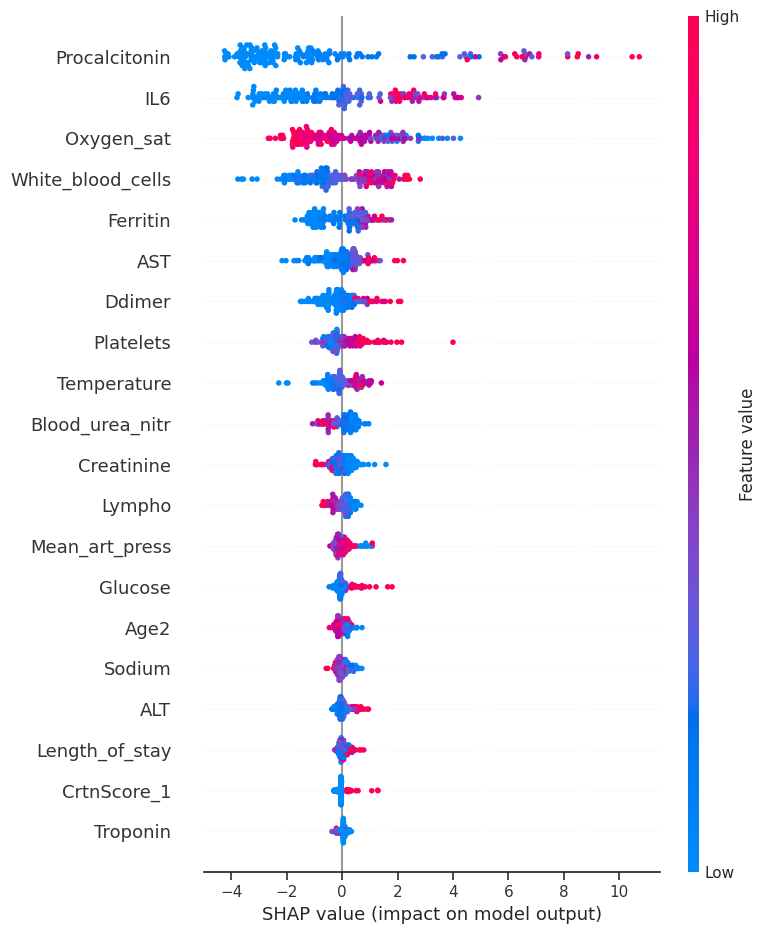

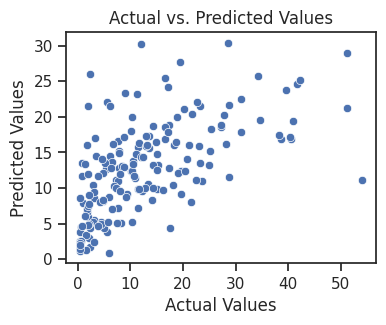

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import shap
from math import sqrt

# Create a Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = rf_regressor.predict(test_x)

mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

# Create object that can calculate SHAP values
explainer = shap.TreeExplainer(rf_regressor)

# Calculate SHAP values for all of test_X
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(4,3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.show()


## KNN Regressor

Mean Absolute Error: 8.152573224489796
KNN MSE: 117.53884228139475
KNN MAPE: 2.153525231143363
KNN RMSE: 10.841533207134255
KNN R²: 0.10397170961442759


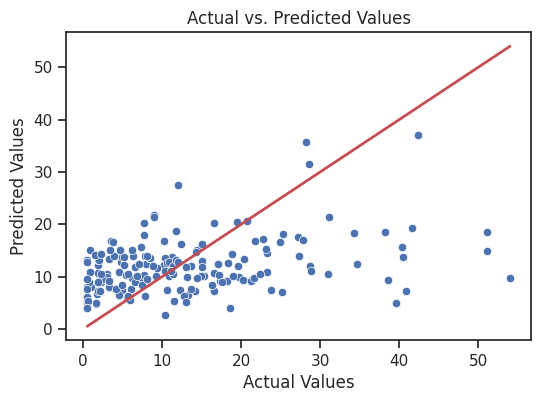

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN Model for Regression
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train, y_train)

# Predictions for KNN model
knn_predictions = knn.predict(X_test)

# Evaluate the KNN model using MSE and MAPE
knn_mse = mean_squared_error(y_test, knn_predictions)
knn_mape = mean_absolute_percentage_error(y_test, knn_predictions)
knn_rmse = np.sqrt(knn_mse)  # RMSE
knn_r2 = r2_score(y_test, knn_predictions)  # R² score
mae = mean_absolute_error(test_y, knn_predictions)

print(f"Mean Absolute Error: {mae}")

print(f'KNN MSE: {knn_mse}')
print(f'KNN MAPE: {knn_mape}')
print(f'KNN RMSE: {knn_rmse}')
print(f'KNN R²: {knn_r2}')

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=knn_predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=2)  # Ideal line for perfect predictions
plt.show()



## Linear Regression

Mean Absolute Error: 7.351324503066238
MSE: 101.01340467555166
RMSE: 10.05054250652927
R²: 0.22994929556331423


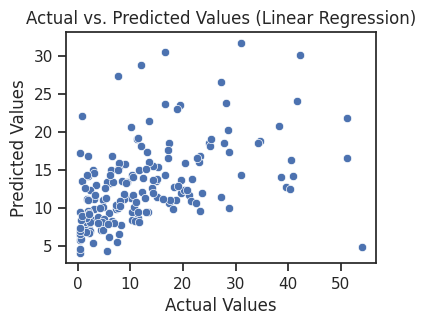

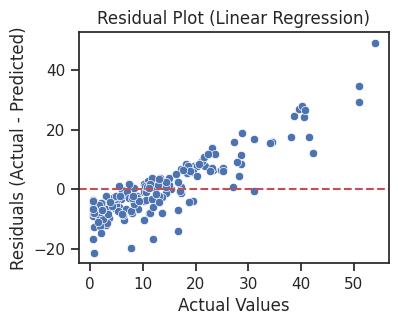

In [54]:
linear_regressor = LinearRegression()
linear_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = linear_regressor.predict(test_x)

# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(4,3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (Linear Regression)")
plt.show()

# Residual plot
residuals = test_y - pred_y
plt.figure(figsize=(4,3))
sns.scatterplot(x=test_y, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Linear Regression)")
plt.show()


## XGB Regressor

Mean Absolute Error: 6.597170622052328
MSE: 91.05935483180619
RMSE: 9.542502545548846
R²: 0.30583153236934946


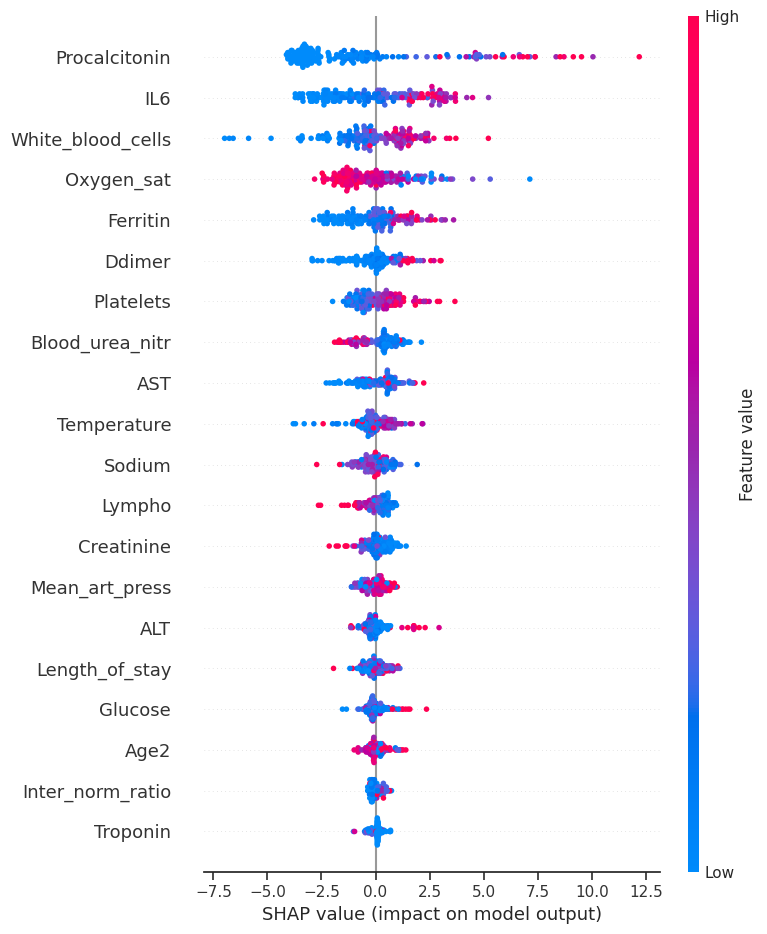

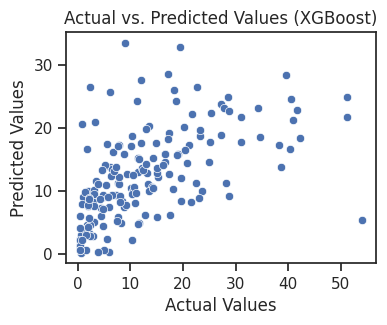

In [55]:
import xgboost as xgb

# Create an XGBoost regression model
xgb_regressor = xgb.XGBRegressor(objective ='reg:squarederror', random_state=42)
xgb_regressor.fit(train_x, train_y)

# Make predictions on the test set
pred_y = xgb_regressor.predict(test_x)

# Evaluate the model
mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)
print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

# Create object that can calculate SHAP values
explainer = shap.TreeExplainer(xgb_regressor)

# Calculate SHAP values for all of test_X
shap_values = explainer.shap_values(test_x)

# Make a summary plot of SHAP values
plt.figure(figsize=(3, 7))
shap.summary_plot(shap_values, test_x, feature_names=X.columns, show=False)
plt.show()

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(4, 3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (XGBoost)")
plt.show()


## ElasticNet

Mean Absolute Error: 7.842038119182549
MSE: 109.95578832656192
RMSE: 10.485980561042535
R²: 0.161779245737539


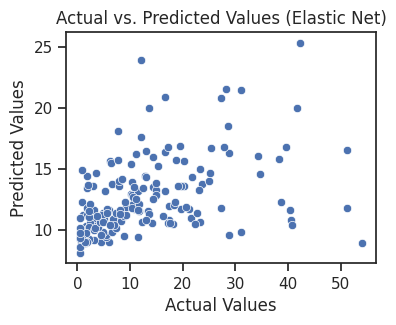

In [56]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Create an Elastic Net model
elastic_net = ElasticNet(alpha=1, l1_ratio=0.9)
elastic_net.fit(train_x, train_y)

# Make predictions on the test set
pred_y = elastic_net.predict(test_x)

mse = mean_squared_error(test_y, pred_y)
mape = mean_absolute_percentage_error(test_y, pred_y)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, pred_y)
mae = mean_absolute_error(test_y, pred_y)

print(f"Mean Absolute Error: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")


# Scatter plot of actual vs. predicted values
plt.figure(figsize=(4,3))
sns.scatterplot(x=test_y, y=pred_y)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (Elastic Net)")
plt.show()
